In [2]:
!pip install einops seaborn --quiet

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from einops import rearrange

In [4]:
files = ['states_2022-06-13-03.csv', 'states_2022-06-20-02.csv', 'states_2022-06-27-01.csv']
columns = ['time', 'icao24', 'lat', 'lon', 'velocity', 'heading', 'geoaltitude']

In [5]:
frames = []
for f in files:
    df = pd.read_csv(f, usecols=columns)
    frames.append(df)
raw_df = pd.concat(frames, ignore_index=True)

In [6]:
print("\n✅ Raw data shape:", raw_df.shape)


✅ Raw data shape: (5662217, 7)


In [7]:
#data cleaning
raw_df.dropna(subset=['icao24', 'lat', 'lon', 'velocity', 'heading', 'geoaltitude'], inplace=True)
raw_df = raw_df[raw_df['velocity'] > 10]

In [8]:
print("\n✅ After cleaning:", raw_df.shape)


✅ After cleaning: (4903199, 7)



✅ Unique Aircraft IDs: 16794


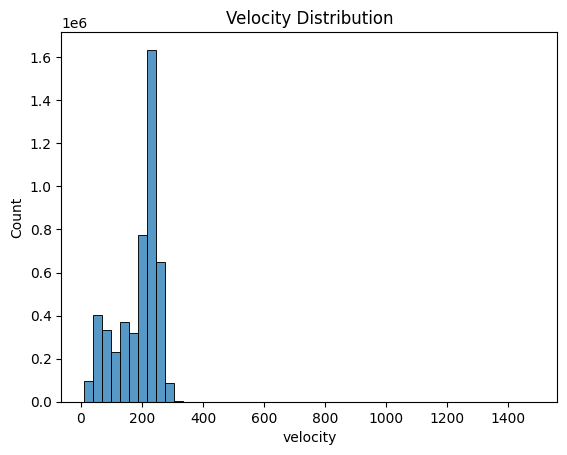

In [9]:
#EDA
print("\n✅ Unique Aircraft IDs:", raw_df['icao24'].nunique())
sns.histplot(raw_df['velocity'], bins=50)
plt.title("Velocity Distribution")
plt.show()

In [10]:
meta_df = pd.read_csv(
    "aircraft-database-complete-2022-06.csv",
    encoding='ISO-8859-1',
    engine='python',
    on_bad_lines='skip',
    header=None
)

print(f"✅ Loaded metadata shape: {meta_df.shape}")
print("🔍 First 3 rows:")
meta_df.head(3)


✅ Loaded metadata shape: (545471, 15)
🔍 First 3 rows:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,N798BC,NaN,Boeing,717-200,NaN,55169,NaN,NaN,NaN,NaN,NaN,NaN,Bcc Equipment Leasing Corp,NaN
2,000000,NaN,NaN,NaN,unknow,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No ADS-B Emitter Category Information


In [11]:
meta_df.columns = [
    "icao24", "registration", "manufacturername", "model", "typecode",
    "operator", "operatorcallsign", "icaoaircrafttype", "categorydescription",
    "status", "built", "owner", "adsb", "acars", "notes"
]


In [12]:
meta_df = meta_df[['icao24', 'manufacturername', 'model', 'typecode', 'categorydescription']]
meta_df.dropna(subset=['icao24', 'categorydescription'], inplace=True)
print("✅ Metadata after cleaning:", meta_df.shape)


✅ Metadata after cleaning: (150028, 5)


In [13]:
#final metadata
meta_df = pd.read_csv(
    "aircraft-database-complete-2022-06.csv",
    encoding='ISO-8859-1',
    engine='python',
    on_bad_lines='skip',
    header=None
)

meta_df.columns = [
    "icao24", "registration", "manufacturername", "model", "typecode",
    "operator", "operatorcallsign", "icaoaircrafttype", "categorydescription",
    "status", "built", "owner", "adsb", "acars", "notes"
]

meta_df = meta_df[['icao24', 'manufacturername', 'model', 'typecode', 'categorydescription']]
meta_df.dropna(subset=['icao24', 'categorydescription'], inplace=True)

print("✅ Metadata ready with shape:", meta_df.shape)


✅ Metadata ready with shape: (150028, 5)


/tmp/ipython-input-13-1348050422.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  meta_df.dropna(subset=['icao24', 'categorydescription'], inplace=True)


In [14]:
#merging datasets
merged = pd.merge(raw_df, meta_df, on='icao24', how='left')
merged.dropna(subset=['categorydescription'], inplace=True)

In [15]:
cat_map = {
    'LandPlane': 'Commercial',
    'Jet': 'Commercial',
    'Helicopter': 'Helicopter',
    'Seaplane': 'Light',
    'Glider': 'Light',
    'Gyrocopter': 'Light',
    'Balloon': 'Light',
    'UAV': 'Light',
    'Dirigible': 'Light',
    'Amphibian': 'Light',
    'Tiltwing': 'Light',
}
merged['class'] = merged['categorydescription'].map(cat_map).fillna('Commercial')
print("\n✅ Class Distribution:")
print(merged['class'].value_counts())


✅ Class Distribution:
class
Commercial    3266605
Name: count, dtype: int64


In [16]:
from tqdm import tqdm

SEQ_LEN = 20
features = ['lat', 'lon', 'velocity', 'heading', 'geoaltitude']

valid_merged = merged.groupby('icao24').filter(lambda x: len(x) > SEQ_LEN)

grouped = valid_merged.groupby('icao24')

sequences, labels = [], []

#tqdm to show progress
for icao, group in tqdm(grouped, desc="Building time series"):
    group = group.sort_values('time')
    data = group[features].to_numpy()
    label_seq = group['class'].to_numpy()

    for i in range(len(data) - SEQ_LEN):
        sequences.append(data[i:i+SEQ_LEN])
        labels.append(label_seq[i + SEQ_LEN])

print("\n✅ Total sequences:", len(sequences))


Building time series: 100%|██████████| 10465/10465 [00:20<00:00, 522.50it/s]


✅ Total sequences: 3055666


In [17]:
# Label Encoding
enc = LabelEncoder()
y = enc.fit_transform(labels)
X = np.array(sequences)

In [18]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

In [19]:
#transformer model
class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim, num_classes, seq_len):
        super().__init__()
        self.embedding = nn.Linear(input_dim, 64)
        self.pos_embedding = nn.Parameter(torch.randn(1, seq_len, 64))
        encoder_layer = nn.TransformerEncoderLayer(d_model=64, nhead=4)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)
        self.head = nn.Sequential(
            nn.LayerNorm(64),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.embedding(x) + self.pos_embedding
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.head(x)

In [21]:
import time

# 30,000 samples
X_small = X[:30000]
y_small = y[:30000]

X_train, X_test, y_train, y_test = train_test_split(X_small, y_small, test_size=0.2, random_state=42)

train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TimeSeriesDataset(X_test, y_test), batch_size=32)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim, num_classes, seq_len):
        super().__init__()
        self.embedding = nn.Linear(input_dim, 64)
        self.pos_embedding = nn.Parameter(torch.randn(1, seq_len, 64))
        encoder_layer = nn.TransformerEncoderLayer(d_model=64, nhead=4)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.head = nn.Sequential(
            nn.LayerNorm(64),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.embedding(x) + self.pos_embedding
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.head(x)

model = TimeSeriesTransformer(input_dim=X.shape[2], num_classes=len(enc.classes_), seq_len=SEQ_LEN).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(5):
    model.train()
    total_loss = 0
    start = time.time()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()
    duration = time.time() - start
    print(f"Epoch {epoch+1}: Loss = {total_loss:.4f} | Time: {duration:.2f} sec")


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1: Loss = 0.0000 | Time: 43.02 sec
Epoch 2: Loss = 0.0000 | Time: 39.29 sec
Epoch 3: Loss = 0.0000 | Time: 39.28 sec
Epoch 4: Loss = 0.0000 | Time: 39.37 sec
Epoch 5: Loss = 0.0000 | Time: 38.61 sec



✅ Classification Report:
              precision    recall  f1-score   support

  Commercial       1.00      1.00      1.00      6000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


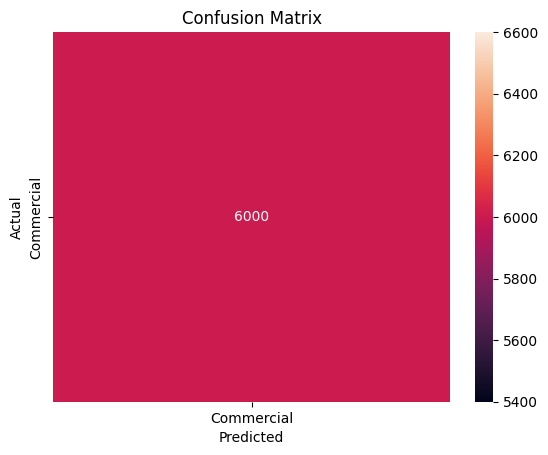

In [22]:
# model Evaluation
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).argmax(1).cpu()
        y_true.extend(yb.numpy())
        y_pred.extend(preds.numpy())

print("\n✅ Classification Report:")
print(classification_report(y_true, y_pred, target_names=enc.classes_))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=enc.classes_, yticklabels=enc.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [23]:
#class distribution
print("Train:", np.bincount(y_train))
print("Test :", np.bincount(y_test))
print(enc.inverse_transform(np.unique(y)))

Train: [24000]
Test : [6000]
['Commercial']


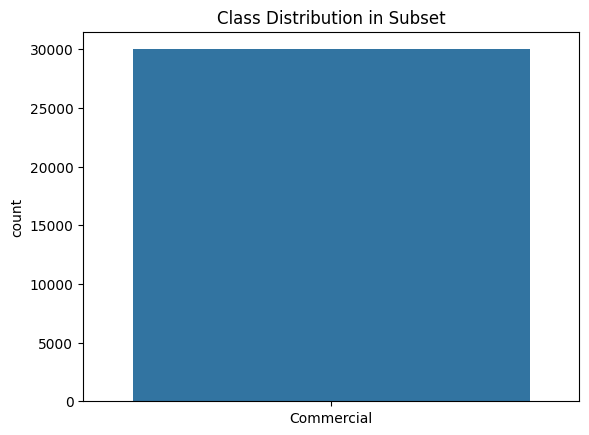

In [24]:
sns.countplot(x=enc.inverse_transform(y_small))
plt.title("Class Distribution in Subset")
plt.show()

In [25]:
#real time prediction
import random
model.eval()

idx = random.randint(0, len(X_test)-1)
new_seq = torch.tensor(X_test[idx:idx+1], dtype=torch.float32).to(device)
pred = model(new_seq).argmax(1).item()

print("\n📡 Real-time Aircraft Sequence Prediction")
print("Predicted class:", enc.classes_[pred])
print("Actual class:", enc.classes_[y_test[idx]])


📡 Real-time Aircraft Sequence Prediction
Predicted class: Commercial
Actual class: Commercial


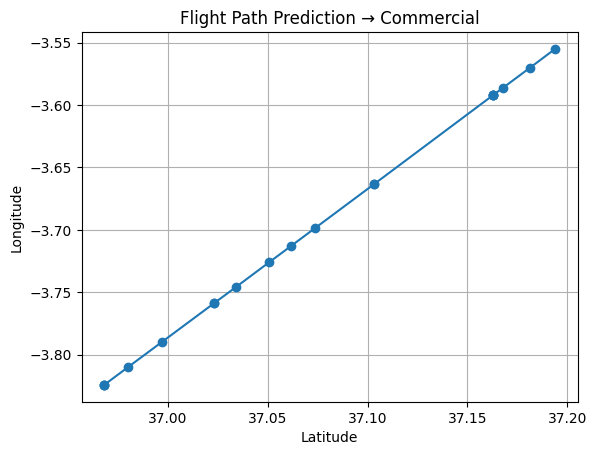

In [26]:
plt.plot(X_test[idx, :, 0], X_test[idx, :, 1], marker='o')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.title(f"Flight Path Prediction → {enc.classes_[pred]}")
plt.grid(True)
plt.show()

In [27]:
#sub types

In [28]:
merged = pd.merge(raw_df, meta_df, on='icao24', how='left')
merged.dropna(subset=['model'], inplace=True)
merged['class'] = merged['model'].str.extract(r'(A[0-9]+|B[0-9]+|C[0-9]+|E[0-9]+|CRJ|DASH|ATR)', expand=False).fillna('Other')

print("\n✅ Aircraft Model Classes:")
print(merged['class'].value_counts())


✅ Aircraft Model Classes:
class
Other    3135594
A320         422
Name: count, dtype: int64


In [30]:
print(merged['model'].value_counts().head(30))


model
Boeing                            1339537
Airbus                             658553
Airbus Industrie                   214933
Bombardier Inc                     166843
Embraer                             87925
Embraer S A                         76949
Cessna                              52742
The Boeing Company                  45814
Boeing Company                      42730
Bombardier                          37477
Bombardier Inc.                     29994
Avions De Transport Regional        21560
Raytheon Aircraft Company           17394
Beech                               16675
The Boeing Co.                      15304
Embraer-empresa Brasileira De       14553
Eurocopter                          14274
Pilatus                             12608
Gulfstream Aerospace                12016
Pilatus Aircraft Ltd                10317
Textron Aviation Inc                10013
Cessna Aircraft Company              9058
Eurocopter Deutschland Gmbh          8345
Bell                        

In [31]:
#filter top models
top_models = ['A320', 'B737', 'CRJ', 'DASH']
merged['class'] = merged['model'].str.extract(r'(' + '|'.join(top_models) + ')', expand=False)
merged['class'] = merged['class'].fillna('Other')
merged = merged[merged['class'] != 'Other']


In [32]:
print(merged['model'].value_counts().head(50))


model
A320-251n    422
Name: count, dtype: int64
